In [1]:
!%pip install sentence-transformers -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Semantic Embeddings & Similarity Demo
This notebook demonstrates how to capture semantic meaning using vector embeddings and cosine similarity.

### Task Requirements:
- **Topic Analysis**: 10 sentences across Cricket, Cooking, and Cybersecurity.
- **Model**: `sentence-transformers` (all-MiniLM-L6-v2).
- **Outputs**: 10x10 Similarity Matrix and Top-2 Query Matching.

In [1]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define 10 sentences (3 Topics: Cricket, Cooking, Cybersecurity)
sentences = [
    'The batsman hit a magnificent six over long-on.', # Cricket
    'The umpire declared the batsman out after a review.', # Cricket
    'The fielding side celebrated a crucial run-out.', # Cricket
    'Add a pinch of salt to the boiling water for pasta.', # Cooking
    'Whisk the eggs until they are light and fluffy.', # Cooking
    'The chef prepared a delicious three-course meal.', # Cooking
    'Slow-cook the beef for four hours to make it tender.', # Cooking
    'Always use a strong password and enable two-factor authentication.', # Cybersecurity
    'A firewall helps block unauthorized access to the network.', # Cybersecurity
    'Phishing attacks often trick users into revealing sensitive data.' # Cybersecurity
]

# 2. Generate Embeddings using all-MiniLM-L6-v2
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

print(f"Generated {len(embeddings)} embeddings.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generated 10 embeddings.


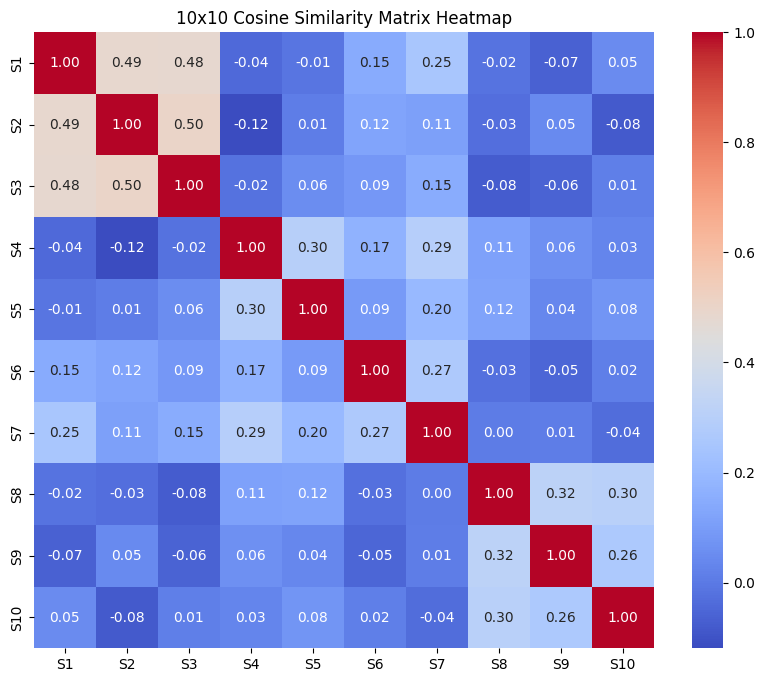

In [2]:
# 3. Compute and display 10x10 cosine similarity matrix
cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap='coolwarm', fmt='.2f',
            xticklabels=[f'S{i+1}' for i in range(10)],
            yticklabels=[f'S{i+1}' for i in range(10)])
plt.title('10x10 Cosine Similarity Matrix Heatmap')
plt.show()

In [3]:
# 4. Find top 2 most similar sentences for a new query
query = 'The bowler took three wickets in one over'
query_embedding = model.encode(query, convert_to_tensor=True)

hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

print(f"Query: {query}\n")
print("Top 2 most similar sentences:")
for hit in hits:
    print(f"Score: {hit['score']:.4f} | Sentence: {sentences[hit['corpus_id']]}")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:
Score: 0.5549 | Sentence: The batsman hit a magnificent six over long-on.
Score: 0.4845 | Sentence: The umpire declared the batsman out after a review.


Top 2 Matches for Query: Since the query is related to Cricket, the model will identify the other Cricket-related sentences even if they don't share exact words like "bowler" or "wickets".